In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os


2026-06-10 09:52:52.524867: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781085172.826466      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781085172.915789      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781085173.659089      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781085173.659148      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781085173.659152      16 computation_placer.cc:177] computation placer alr

In [2]:

BASE_DIR = '/kaggle/input/datasets/jonathanoheix/face-expression-recognition-dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'images', 'train')
VAL_DIR   = os.path.join(BASE_DIR, 'images', 'validation')

CLASSES = sorted(os.listdir(TRAIN_DIR))

print(CLASSES)



['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


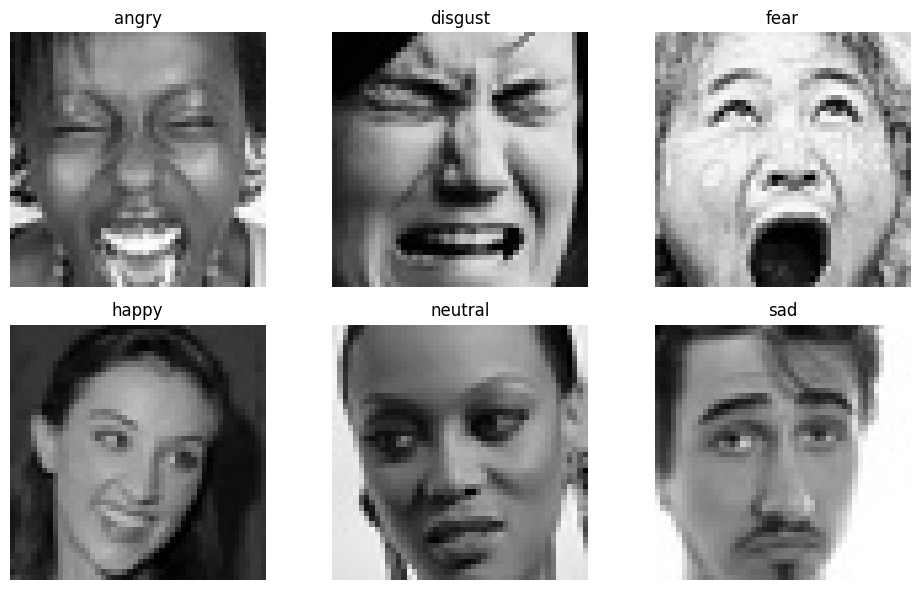

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for ax, cls in zip(axes.flat, CLASSES):
    img_path = os.path.join(TRAIN_DIR, cls, os.listdir(os.path.join(TRAIN_DIR, cls))[0])
    img = cv2.imread(img_path)
    
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')
plt.tight_layout()
plt.show()


In [4]:
IMG_SIZE = 64
def load_data(directory):
    images, labels = [], []
    for cls in CLASSES:
        folder = os.path.join(directory, cls)
        for fname in os.listdir(folder):
            img = cv2.imread(os.path.join(folder, fname))
            if img is None:
                continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img)
            labels.append(cls)
    return np.array(images), np.array(labels)

X_train_raw, y_train_raw = load_data(TRAIN_DIR)
X_val_raw,  y_val_raw  = load_data(VAL_DIR)

print(X_train_raw.shape, X_val_raw.shape)

(28821, 64, 64, 3) (7066, 64, 64, 3)


In [5]:
X_train = X_train_raw / 255.0
X_val  = X_val_raw  / 255.0


Label_en = LabelEncoder()
y_train = to_categorical(Label_en.fit_transform(y_train_raw))
y_val  = to_categorical(Label_en.transform(y_val_raw))

print("Classes:", Label_en.classes_)
print("X_train:", X_train.shape, "| y_train:", y_val.shape)

Classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']
X_train: (28821, 64, 64, 3) | y_train: (7066, 7)


In [6]:
model = Sequential([
    Conv2D(16, (3,3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    
    MaxPooling2D(2,2),
     
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    
    
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(len(CLASSES), activation='softmax')])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-10 09:56:46.672720: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,785,255 (33.51 MB)

 Trainable params: 8,784,263 (33.51 MB)

 Non-trainable params: 992 (3.88 KB)

In [7]:
model.compile(optimizer='adamW', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=15
)

Epoch 1/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 656s 722ms/step - accuracy: 0.2631 - loss: 1.8400 - val_accuracy: 0.2922 - val_loss: 1.7544
Epoch 2/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 643s 714ms/step - accuracy: 0.3104 - loss: 1.6677 - val_accuracy: 0.3054 - val_loss: 1.6666
Epoch 3/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 641s 712ms/step - accuracy: 0.3249 - loss: 1.6119 - val_accuracy: 0.3508 - val_loss: 1.5573
Epoch 4/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 681s 711ms/step - accuracy: 0.3584 - loss: 1.5685 - val_accuracy: 0.4219 - val_loss: 1.4352
Epoch 5/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 675s 704ms/step - accuracy: 0.3882 - loss: 1.5040 - val_accuracy: 0.4418 - val_loss: 1.4363
Epoch 6/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 633s 702ms/step - accuracy: 0.4163 - loss: 1.4553 - val_accuracy: 0.4611 - val_loss: 1.4750
Epoch 7/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 638s 708ms/step - accuracy: 0.4268 - loss: 1.4285 - val_accuracy: 0.4557 - val_loss: 1.3903
Epoch 8/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 634s 703ms/step - accuracy: 0.4589 -

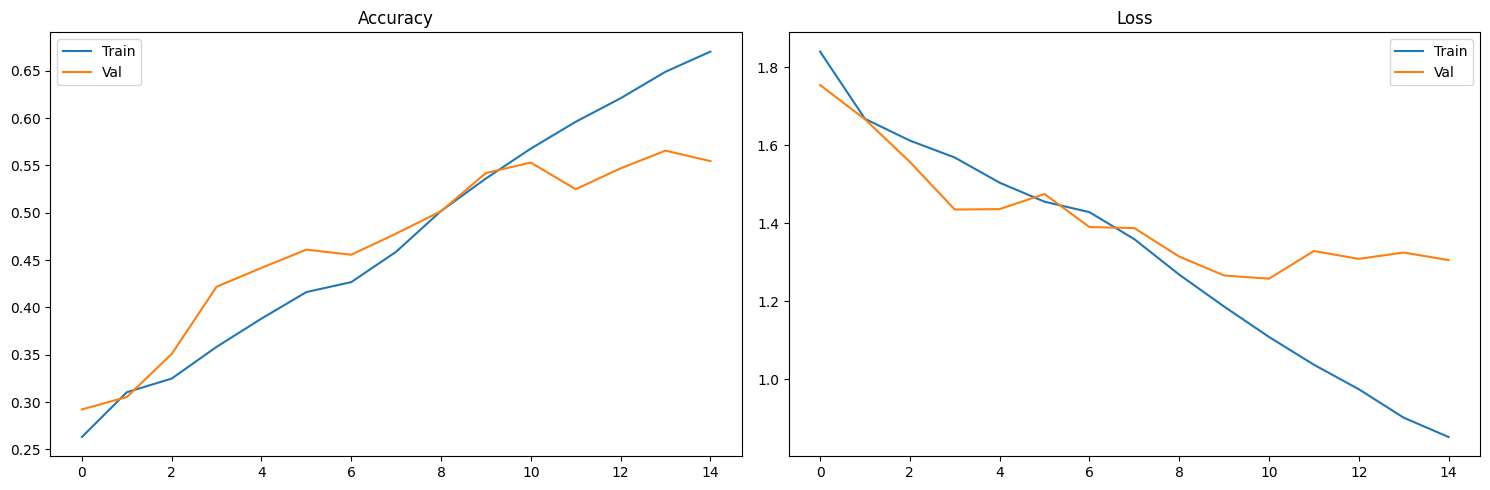

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

